In [2]:
#Perform Google Colab installs (if running in Google Colab)

import os

if "COLAB_GPU" in os.environ:
    print("[INFO] Running in Google Colab, installing requirements.")
    !pip install PyMuPDF # for reading PDFs with Python
    !pip install tqdm# for progress bars (Commented out: package not found)
    !pip install sentence-transformers # for embedding models
    !pip install accelerate # for quantization model loading
    !pip install bitsandbytes # for quantizing models (less storage space)
    !pip install flash-attn --no-build-isolation # for faster attention mechanism = faster LLM inference (Commented out: package not found or requires specific installation)

[INFO] Running in Google Colab, installing requirements.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 57.0 MB/s eta 0:00:00
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `pip install tqdm# for progress bars (Commented out: package not found)'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 75.8 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [3]:
!pip uninstall -y torch torchvision torchaudio transformers sentence-transformers
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -U transformers sentence-transformers


Found existing installation: torch 2.10.0+cpu
Uninstalling torch-2.10.0+cpu:
  Successfully uninstalled torch-2.10.0+cpu
Found existing installation: torchvision 0.25.0+cpu
Uninstalling torchvision-0.25.0+cpu:
  Successfully uninstalled torchvision-0.25.0+cpu
Found existing installation: torchaudio 2.10.0+cpu
Uninstalling torchaudio-2.10.0+cpu:
  Successfully uninstalled torchaudio-2.10.0+cpu
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: sentence-transformers 5.4.1
Uninstalling sentence-transformers-5.4.1:
  Successfully uninstalled sentence-transformers-5.4.1
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 570.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 22.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 84.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━

In [4]:
import os
import requests

# Path where PDF will be saved
pdf_path = "human-nutrition-text.pdf"

# Download only if file does not already exist
if not os.path.exists(pdf_path):
    print("File doesn't exist, downloading...")

    # PDF URL
    url = "https://pressbooks.oer.hawaii.edu/humannutrition2/open/download?type=pdf"

    # Send GET request
    response = requests.get(url)

    # Check if request was successful
    if response.status_code == 200:
        # Save file in binary mode
        with open(pdf_path, "wb") as file:
            file.write(response.content)

        print(f"The file has been downloaded and saved as {pdf_path}")
    else:
        print(f"Failed to download the file. Status code: {response.status_code}")

else:
    print(f"File {pdf_path} already exists.")


File doesn't exist, downloading...
The file has been downloaded and saved as human-nutrition-text.pdf


In [5]:
# Install required libraries (run once)
!pip install pymupdf tqdm

import fitz  # PyMuPDF
from tqdm.auto import tqdm

# -------- Text Formatter --------
def text_formatter(text: str) -> str:
    """
    Performs minor formatting on extracted text.
    """
    cleaned_text = text.replace("\n", " ").strip()
    return cleaned_text


# -------- Open & Read PDF --------
def open_and_read_pdf(pdf_path: str) -> list[dict]:
    """
    Opens a PDF file, reads its text page by page,
    and collects useful statistics.
    """

    doc = fitz.open(pdf_path)
    pages_and_texts = []

    for page_number, page in tqdm(enumerate(doc), total=len(doc)):
        text = page.get_text()
        text = text_formatter(text)

        pages_and_texts.append({
            "page_number": page_number,
            "page_char_count": len(text),
            "page_word_count": len(text.split()),
            "page_sentence_count_raw": len(text.split(".")),
            "page_token_count_estimate": len(text) / 4,  # Approx: 1 token ≈ 4 chars
            "text": text
        })

    doc.close()
    return pages_and_texts


# -------- Run the Function --------
pdf_path = "human-nutrition-text.pdf"
pages_and_texts = open_and_read_pdf(pdf_path)

# Show first 2 pages
pages_and_texts[:2]


  0%|          | 0/1208 [00:00<?, ?it/s]

[{'page_number': 0,
  'page_char_count': 29,
  'page_word_count': 4,
  'page_sentence_count_raw': 1,
  'page_token_count_estimate': 7.25,
  'text': 'Human Nutrition: 2020 Edition'},
 {'page_number': 1,
  'page_char_count': 0,
  'page_word_count': 0,
  'page_sentence_count_raw': 1,
  'page_token_count_estimate': 0.0,
  'text': ''}]

In [6]:
import random

random.sample(pages_and_texts, k=3)

[{'page_number': 979,
  'page_char_count': 1151,
  'page_word_count': 176,
  'page_sentence_count_raw': 10,
  'page_token_count_estimate': 287.75,
  'text': 'Image by  Cosmed /  CC BY-SA  3.0  Muscle Strength  Muscle strength is developed and maintained by weight or  resistance training that often is called anaerobic exercise. Anaerobic  exercise consists of short duration, high intensity movements that  rely on immediately available energy sources and require little or  no oxygen during the activity. This type of high intensity training  is used to build muscle strength by short, high intensity activities.  Building muscle mass is not just crucial for athletes and  bodybuilders—building muscle strength and endurance is important  for children, seniors, and everyone in between. The support that  your muscles provide allows you to work, play, and live more  efficiently. Strength training involves the use of resistance  machines, resistance bands, free weights, or other tools. However,  

In [7]:
import pandas as pd
df=pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count_estimate,text
0,0,29,4,1,7.25,Human Nutrition: 2020 Edition
1,1,0,0,1,0.00,
2,2,320,42,1,80.00,Human Nutrition: 2020 Edition UNIVERSITY OF ...
3,3,212,30,3,53.00,Human Nutrition: 2020 Edition by University of...
4,4,797,116,3,199.25,Contents Preface University of Hawai‘i at Mā...


**Fixed-Size Character-Based Chunking**

In [8]:
# -------- Text Chunking Function --------
def chunk_text(text: str, chunk_size: int = 500) -> list[str]:
    """
    Splits text into chunks of approximately chunk_size characters.
    Keeps whole words intact.
    """
    chunks = []
    current_chunk = ""
    words = text.split()

    for word in words:
        # +1 accounts for space
        if len(current_chunk) + len(word) + 1 <= chunk_size:
            current_chunk += word + " "
        else:
            chunks.append(current_chunk.strip())
            current_chunk = word + " "

    # Add final chunk
    if current_chunk:
        chunks.append(current_chunk.strip())

    return chunks


# -------- Chunk All PDF Pages --------
# -------- Chunk Text Function --------
def chunk_text(text: str, chunk_size: int = 500) -> list[str]:
    """
    Splits text into chunks of approximately chunk_size characters.
    Keeps words intact.
    """
    chunks = []
    current_chunk = ""
    words = text.split()

    for word in words:
        if len(current_chunk) + len(word) + 1 <= chunk_size:
            current_chunk += word + " "
        else:
            chunks.append(current_chunk.strip())
            current_chunk = word + " "

    if current_chunk:
        chunks.append(current_chunk.strip())

    return chunks


# -------- Chunk PDF Pages Function --------
def chunk_pdf_pages(pages_and_texts: list[dict], chunk_size: int = 500) -> list[dict]:
    """
    Takes PDF pages with text and splits them into chunks.

    Returns:
        A list of dictionaries with:
        - page_number
        - chunk_index
        - chunk_char_count
        - chunk_word_count
        - chunk_token_count (rough estimate)
        - chunk_text
    """
    all_chunks = []

    for page in pages_and_texts:
        page_number = page["page_number"]
        page_text = page["text"]

        chunks = chunk_text(page_text, chunk_size=chunk_size)

        for i, chunk in enumerate(chunks):
            all_chunks.append({
                "page_number": page_number,
                "chunk_index": i,
                "chunk_char_count": len(chunk),
                "chunk_word_count": len(chunk.split()),
                "chunk_token_count": len(chunk) / 4,  # rough token estimate
                "chunk_text": chunk
            })

    return all_chunks


# -------- Example Usage --------
chunked_pages = chunk_pdf_pages(pages_and_texts, chunk_size=500)

print(f"Total chunks: {len(chunked_pages)}")

print(f"\nFirst chunk (page {chunked_pages[0]['page_number']}):")
print(chunked_pages[0]['chunk_text'][:200] + "...")


Total chunks: 3321

First chunk (page 0):
Human Nutrition: 2020 Edition...


In [9]:
import random
import textwrap


# -------- Scattered Sampling --------
def scattered_indices(n: int, k: int, jitter_frac: float = 0.08) -> list[int]:
    if k == 0:
        return []

    if k == 1:
        return [random.randrange(n)]

    anchors = [int(round(i * (n - 1) / (k - 1))) for i in range(k)]

    out = []
    seen = set()
    radius = max(1, int(n * jitter_frac))

    for a in anchors:
        lo = max(0, a - radius)
        hi = min(n - 1, a + radius)
        j = random.randint(lo, hi)

        if j not in seen:
            out.append(j)
            seen.add(j)

    while len(out) < k:
        r = random.randrange(n)
        if r not in seen:
            out.append(r)
            seen.add(r)

    return out


# -------- Draw Boxed Chunk --------
def _draw_boxed_chunk(c: dict, wrap_at: int = 96) -> str:
    header = (
        f"Chunk | page {c['page_number']} | idx {c['chunk_index']} | "
        f"chars {c['chunk_char_count']} | "
        f"words {c['chunk_word_count']} | "
        f"~tokens {int(c['chunk_token_count'])}"
    )

    wrapped_lines = textwrap.wrap(
        c["chunk_text"],
        width=wrap_at,
        break_long_words=False,
        replace_whitespace=False
    )

    content_width = max([len(header)] + [len(line) for line in wrapped_lines])
    box_width = content_width + 4  # padding

    top = "+" + "-" * (box_width - 2) + "+"
    hline = "| " + header.ljust(box_width - 4) + " |"
    sep = "|" + "-" * (box_width - 2) + "|"

    body = "\n".join(
        "| " + line.ljust(box_width - 4) + " |"
        for line in wrapped_lines
    )

    bottom = "+" + "-" * (box_width - 2) + "+"

    return "\n".join([top, hline, sep, body, bottom])


# -------- Show Random Chunks --------
def show_random_chunks(
    pages_and_texts: list,
    chunk_size: int = 500,
    k: int = 5,
    seed: int | None = 42
):
    if seed is not None:
        random.seed(seed)

    all_chunks = chunk_pdf_pages(pages_and_texts, chunk_size=chunk_size)

    if not all_chunks:
        print("No chunks to display.")
        return

    idxs = scattered_indices(len(all_chunks), k)

    print(f"Showing {len(idxs)} scattered random chunks out of {len(all_chunks)} total:\n")

    for i, idx in enumerate(idxs, 1):
        print(f"#{i}")
        print(_draw_boxed_chunk(all_chunks[idx]))
        print()


# -------- Run Safely --------
assert "pages_and_texts" in globals(), \
    "Run: pages_and_texts = open_and_read_pdf(pdf_path) first."

show_random_chunks(pages_and_texts, chunk_size=500, k=5 , seed=42)


Showing 5 scattered random chunks out of 3321 total:

#1
+--------------------------------------------------------------------------------------------------+
| Chunk | page 32 | idx 0 | chars 290 | words 49 | ~tokens 72                                      |
|--------------------------------------------------------------------------------------------------|
| Skylar Hara Skylar Hara is an undergraduate student student in the Tropical Agriculture and the  |
| Environment program at the University of Hawai‘i at Mānoa. She has a growing love for plants and |
| hopes to go to graduate school to conduct research in the future. About the Contributors |       |
| xxxiii                                                                                           |
+--------------------------------------------------------------------------------------------------+

#2
+-------------------------------------------------------------------------------------------------+
| Chunk | page 239 | idx 0 | ch

**Semantic Chunking**

In [10]:
!pip -q install --upgrade "sentence-transformers==3.0.1" "transformers<5,>=4.41" scikit-learn nitk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 16.0 MB/s eta 0:00:00


In [11]:
# Install if needed
!pip install sentence-transformers nltk scikit-learn

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
import numpy as np

# Download tokenizer once
nltk.download("punkt", quiet=True)

# Load model once (GPU will be used automatically if available)
semantic_model = SentenceTransformer("all-MiniLM-L6-v2")


# -------- Semantic Chunking --------
def semantic_chunk_text(
    text: str,
    similarity_threshold: float = 0.8,
    max_tokens: int = 500
) -> list[str]:
    """
    Splits text into semantic chunks based on sentence similarity
    and approximate token limit.
    """

    sentences = nltk.sent_tokenize(text)

    if not sentences:
        return []

    embeddings = semantic_model.encode(sentences)

    chunks = []
    current_chunk = [sentences[0]]
    current_embedding = embeddings[0]

    for i in range(1, len(sentences)):
        similarity = cosine_similarity(
            [current_embedding],
            [embeddings[i]]
        )[0][0]

        chunk_token_count = len(" ".join(current_chunk)) // 4  # rough token estimate

        if similarity >= similarity_threshold and chunk_token_count < max_tokens:
            current_chunk.append(sentences[i])
            # Update embedding as mean of current chunk
            current_embedding = np.mean([current_embedding, embeddings[i]], axis=0)
        else:
            chunks.append(" ".join(current_chunk))
            current_chunk = [sentences[i]]
            current_embedding = embeddings[i]

    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks
from tqdm.auto import tqdm


def semantic_chunk_pdf_pages(
    pages_and_texts: list[dict],
    similarity_threshold: float = 0.8,
    max_tokens: int = 500
) -> list[dict]:
    """
    Takes PDF pages with text and splits them into semantic chunks.

    Returns:
        List of dictionaries containing:
        - page_number
        - chunk_index
        - chunk_char_count
        - chunk_word_count
        - chunk_token_count (rough estimate)
        - chunk_text
    """

    all_chunks = []

    for page in tqdm(pages_and_texts, desc="Semantic chunking pages"):
        page_number = page["page_number"]
        page_text = page["text"]

        chunks = semantic_chunk_text(
            page_text,
            similarity_threshold=similarity_threshold,
            max_tokens=max_tokens
        )

        for i, chunk in enumerate(chunks):
            all_chunks.append({
                "page_number": page_number,
                "chunk_index": i,
                "chunk_char_count": len(chunk),
                "chunk_word_count": len(chunk.split()),
                "chunk_token_count": len(chunk) / 4,  # rough token estimate
                "chunk_text": chunk
            })

    return all_chunks

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [12]:
import nltk

# Download tokenizer (only needed once)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True) # Download punkt_tab resource

# Run semantic chunking
semantic_chunked_pages = semantic_chunk_pdf_pages(
    pages_and_texts,
    similarity_threshold=0.75,
    max_tokens=500
)

print(f"Total semantic chunks: {len(semantic_chunked_pages)}")

print(f"\nFirst semantic chunk (page {semantic_chunked_pages[0]['page_number']}):")
print(semantic_chunked_pages[0]["chunk_text"][:200] + "...")

Semantic chunking pages:   0%|          | 0/1208 [00:00<?, ?it/s]

Total semantic chunks: 12016

First semantic chunk (page 0):
Human Nutrition: 2020 Edition...


In [13]:
import random
import textwrap


# -------- Draw Boxed Semantic Chunk --------
def _draw_boxed_chunk(c: dict, wrap_at: int = 96) -> str:
    approx_tokens = c.get(
        "chunk_token_count",
        len(c.get("chunk_text", "")) / 4
    )

    header = (
        f"Chunk | page {c['page_number']} | idx {c['chunk_index']} | "
        f"chars {c['chunk_char_count']} | "
        f"words {c['chunk_word_count']} | "
        f"~tokens {round(approx_tokens, 2)}"
    )

    wrapped_lines = textwrap.wrap(
        c["chunk_text"],
        width=wrap_at,
        break_long_words=False,
        replace_whitespace=False
    )

    content_width = max([len(header)] + [len(line) for line in wrapped_lines])
    box_width = content_width + 4  # side padding

    top = "+" + "-" * (box_width - 2) + "+"
    hline = "| " + header.ljust(box_width - 4) + " |"
    sep = "|" + "-" * (box_width - 2) + "|"

    if wrapped_lines:
        body = "\n".join(
            "| " + line.ljust(box_width - 4) + " |"
            for line in wrapped_lines
        )
    else:
        body = "| " + "".ljust(box_width - 4) + " |"

    bottom = "+" + "-" * (box_width - 2) + "+"

    return "\n".join([top, hline, sep, body, bottom])



# -------- Scattered Sampling --------
def _scattered_indices(n: int, k: int) -> list[int]:
    if k <= 0:
        return []

    if k == 1:
        return [random.randrange(n)]

    step = max(1, n // k)
    indices = list(range(0, n, step))[:k]

    return indices


# -------- Show Random Semantic Chunks --------
def show_random_semantic_chunks(
    semantic_chunked_pages: list[dict],
    k: int = 5,
    seed: int | None = 42
):
    if seed is not None:
        random.seed(seed)

    n = len(semantic_chunked_pages)

    if n == 0:
        print("No semantic chunks to display.")
        return

    idxs = _scattered_indices(n, k)

    print(f"Showing {len(idxs)} scattered random SEMANTIC chunks out of {n} total:\n")

    for i, idx in enumerate(idxs, 1):
        print(f"#{i}")
        print(_draw_boxed_chunk(semantic_chunked_pages[idx]))
        print()


# -------- Run Safely --------
assert "semantic_chunked_pages" in globals() and len(semantic_chunked_pages) > 0, \
    "Run semantic_chunk_pdf_pages() first to define semantic_chunked_pages."

show_random_semantic_chunks(semantic_chunked_pages, k=5, seed=42)

Showing 5 scattered random SEMANTIC chunks out of 12016 total:

#1
+------------------------------------------------------------+
| Chunk | page 0 | idx 0 | chars 29 | words 4 | ~tokens 7.25 |
|------------------------------------------------------------|
| Human Nutrition: 2020 Edition                              |
+------------------------------------------------------------+

#2
+----------------------------------------------------------------------------------------------+
| Chunk | page 286 | idx 2 | chars 125 | words 16 | ~tokens 31.25                              |
|----------------------------------------------------------------------------------------------|
| The  products  of  bacterial  digestion  of  these  slow-releasing  carbohydrates are short- |
| chain fatty acids and some gases.                                                            |
+----------------------------------------------------------------------------------------------+

#3
+---------------------------

**Recursvie Chunking**

In [14]:
# Install once if needed
!pip install nltk tqdm

import nltk
from tqdm.auto import tqdm

# Download tokenizer safely
nltk.download("punkt", quiet=True)


# ---------------- Recursive Text Chunking ----------------
def recursive_chunk_text(
    text: str,
    max_chunk_size: int = 1000,
    min_chunk_size: int = 100
) -> list[str]:
    """
    Recursively splits text into chunks within size constraints.

    Splitting priority:
        1. Double newline
        2. Single newline
        3. Sentence-level fallback
    """

    def split_chunk(chunk: str) -> list[str]:

        chunk = chunk.strip()

        # Base case
        if len(chunk) <= max_chunk_size:
            return [chunk]

        # 1️⃣ Split by double newline
        sections = chunk.split("\n\n")
        if len(sections) > 1:
            result = []
            for section in sections:
                if section.strip():
                    result.extend(split_chunk(section))
            return result

        # 2️⃣ Split by single newline
        sections = chunk.split("\n")
        if len(sections) > 1:
            result = []
            for section in sections:
                if section.strip():
                    result.extend(split_chunk(section))
            return result

        # 3️⃣ Fallback: Sentence-based packing
        sentences = nltk.sent_tokenize(chunk)

        chunks = []
        current_chunk = []
        current_size = 0

        for sentence in sentences:
            sentence_length = len(sentence)

            if current_size + sentence_length > max_chunk_size:
                if current_chunk:
                    combined = " ".join(current_chunk)
                    if len(combined) >= min_chunk_size:
                        chunks.append(combined)

                current_chunk = [sentence]
                current_size = sentence_length
            else:
                current_chunk.append(sentence)
                current_size += sentence_length

        if current_chunk:
            combined = " ".join(current_chunk)
            if len(combined) >= min_chunk_size:
                chunks.append(combined)

        return chunks

    return split_chunk(text)


# ---------------- Recursive PDF Chunking ----------------
def recursive_chunk_pdf_pages(
    pages_and_texts: list[dict],
    max_chunk_size: int = 1000,
    min_chunk_size: int = 100
) -> list[dict]:
    """
    Splits PDF pages into recursive structured chunks.

    Returns:
        List of dictionaries with:
        - page_number
        - chunk_index
        - chunk_char_count
        - chunk_word_count
        - chunk_token_count (rough estimate)
        - chunk_text
    """

    all_chunks = []

    for page in tqdm(pages_and_texts, desc="Recursive chunking pages"):
        page_number = page["page_number"]
        page_text = page["text"]

        chunks = recursive_chunk_text(
            page_text,
            max_chunk_size=max_chunk_size,
            min_chunk_size=min_chunk_size
        )

        for i, chunk in enumerate(chunks):
            all_chunks.append({
                "page_number": page_number,
                "chunk_index": i,
                "chunk_char_count": len(chunk),
                "chunk_word_count": len(chunk.split()),
                "chunk_token_count": len(chunk) // 4,  # rough estimate
                "chunk_text": chunk
            })

    return all_chunks


In [15]:
recursive_chunked_pages = recursive_chunk_pdf_pages(
    pages_and_texts,
    max_chunk_size=800,
    min_chunk_size=100
)

print(f"Total recursive chunks: {len(recursive_chunked_pages)}")

print(f"\nFirst recursive chunk (page {recursive_chunked_pages[0]['page_number']}):")

print(recursive_chunked_pages[0]['chunk_text'][:200] + "...")


Recursive chunking pages:   0%|          | 0/1208 [00:00<?, ?it/s]

Total recursive chunks: 2353

First recursive chunk (page 0):
Human Nutrition: 2020 Edition...


**Structural Chunking Using all-MiniLM-L6-v2 model**

In [16]:
import random
import textwrap


def _scattered_indices(n: int, k: int, jitter_frac: float = 0.08) -> list[int]:
    """Generate k roughly evenly spaced random indices with jitter."""

    if k <= 0:
        return []
    if k == 1:
        return [random.randrange(n)]

    anchors = [int(round(i * (n - 1) / (k - 1))) for i in range(k)]
    radius = max(1, int(n * jitter_frac))

    out = []
    seen = set()

    for a in anchors:
        lo = max(0, a - radius)
        hi = min(n - 1, a + radius)
        j = random.randint(lo, hi)

        if j not in seen:
            out.append(j)
            seen.add(j)

    while len(out) < k:
        r = random.randrange(n)
        if r not in seen:
            out.append(r)
            seen.add(r)

    return out


def _draw_boxed_chunk(c: dict, wrap_at: int = 96) -> str:
    """Format one chunk into a clean ASCII box."""

    approx_tokens = c.get("chunk_token_count", len(c.get("chunk_text", "")) // 4)

    header = (
        f"Chunk | Page {c['page_number']} | Index {c['chunk_index']} | "
        f"Chars {c['chunk_char_count']} | Words {c['chunk_word_count']} | "
        f"Tokens ~{round(approx_tokens, 2)}"
    )

    wrapped_lines = textwrap.wrap(
        c["chunk_text"],
        width=wrap_at,
        break_long_words=False,
        replace_whitespace=False,
    )

    content_width = max([len(line) for line in wrapped_lines], default=0)
    box_width = max(len(header), content_width) + 4

    top = "+" + "-" * (box_width - 2) + "+"
    header_line = "| " + header.ljust(box_width - 4) + " |"
    separator = "+" + "-" * (box_width - 2) + "+"

    body = "\n".join(
        "| " + line.ljust(box_width - 4) + " |"
        for line in wrapped_lines
    ) or "| " + "".ljust(box_width - 4) + " |"

    bottom = "+" + "-" * (box_width - 2) + "+"

    return "\n".join([top, header_line, separator, body, bottom])


def show_random_recursive_chunks(
    recursive_chunked_pages: list[dict],
    k: int = 5,
    seed: int | None = 42,
):
    """Pretty-print k scattered random recursive chunks."""

    if seed is not None:
        random.seed(seed)

    n = len(recursive_chunked_pages)

    assert n > 0, "No recursive chunks to display. Did you run the recursive chunking first?"

    idxs = _scattered_indices(n, k)

    print(f"Showing {len(idxs)} scattered random RECURSIVE chunks out of {n} total:\n")

    for i, idx in enumerate(idxs, 1):
        print(f"#{i}")
        print(_draw_boxed_chunk(recursive_chunked_pages[idx]))
        print()


# Run this after recursive_chunked_pages is created
assert "recursive_chunked_pages" in globals() and len(recursive_chunked_pages) > 0, \
    "Run your recursive chunking code first."

show_random_recursive_chunks(recursive_chunked_pages, k=5, seed=42)

Showing 5 scattered random RECURSIVE chunks out of 2353 total:

#1
+-------------------------------------------------------------------------------------------------+
| Chunk | Page 97 | Index 0 | Chars 737 | Words 116 | Tokens ~184                                 |
+-------------------------------------------------------------------------------------------------+
| •  Explain the anatomy and physiology of the  digestive system and other supporting organ       |
| systems  •  Describe the relationship between diet and each of  the organ systems  •  Describe  |
| the process of calculating Body Mass  Index (BMI)  The Native Hawaiians believed there was a    |
| strong connection  between health and food. Around the world, other cultures had  similar views |
| of food and its relationship with health. A famous  quote by the Greek physician Hippocrates    |
| over two thousand years  ago, “Let food be thy medicine and medicine be thy food” bear much     |
| relevance on our food choices a

In [17]:
import re


# -------------------------------------------------
# 1️⃣ Detect Chapter Header Page
# -------------------------------------------------
def _is_chapter_header_page(text: str) -> bool:
    """
    Detects if page contains the recurring
    'University of Hawai'i at Manoa' header.
    """
    pattern = r"university\s+of\s+hawai[’'`i]*"
    return re.search(pattern, text, flags=re.IGNORECASE) is not None


# -------------------------------------------------
# 2️⃣ Guess Chapter Title
# -------------------------------------------------
def _guess_title_from_page(text: str) -> str:
    """
    Extracts chapter title from text before the header.
    Falls back to first 120 characters if needed.
    """
    pattern = r"university\s+of\s+hawai[’'`i]*"
    match = re.search(pattern, text, flags=re.IGNORECASE)

    if match:
        title = text[:match.start()].strip()
        title = re.sub(r"\s+", " ", title)

        if 10 <= len(title) <= 180:
            return title

    cleaned = re.sub(r"\s+", " ", text).strip()
    return cleaned[:120] if cleaned else "Untitled Chapter"


# -------------------------------------------------
# 3️⃣ Build Chapter Chunks
# -------------------------------------------------
def chapter_chunk_pdf_pages(pages_and_texts: list[dict]) -> list[dict]:
    """
    Groups pages into chapter-level chunks.

    Returns:
    [
        {
            "chapter_index": int,
            "title": str,
            "page_start": int,
            "page_end": int,
            "chunk_char_count": int,
            "chunk_word_count": int,
            "chunk_token_count": float,
            "chunk_text": str
        }
    ]
    """

    if not pages_and_texts:
        return []

    # Find chapter start page indices
    chapter_starts = []
    for i, page in enumerate(pages_and_texts):
        if _is_chapter_header_page(page["text"]):
            chapter_starts.append(i)

    # If no chapter headers found → treat entire document as one chapter
    if not chapter_starts:
        all_text = " ".join(p["text"] for p in pages_and_texts).strip()

        return [{
            "chapter_index": 0,
            "title": _guess_title_from_page(pages_and_texts[0]["text"]),
            "page_start": pages_and_texts[0]["page_number"],
            "page_end": pages_and_texts[-1]["page_number"],
            "chunk_char_count": len(all_text),
            "chunk_word_count": len(all_text.split()),
            "chunk_token_count": round(len(all_text) / 4, 2),
            "chunk_text": all_text
        }]

    # Build chapter ranges
    chapter_chunks = []

    for ci, start_idx in enumerate(chapter_starts):

        # Determine end index
        if ci + 1 < len(chapter_starts):
            end_idx = chapter_starts[ci + 1] - 1
        else:
            end_idx = len(pages_and_texts) - 1

        pages = pages_and_texts[start_idx:end_idx + 1]
        text_concat = " ".join(p["text"] for p in pages).strip()
        title = _guess_title_from_page(pages[0]["text"])

        chapter_chunks.append({
            "chapter_index": ci,
            "title": title,
            "page_start": pages[0]["page_number"],
            "page_end": pages[-1]["page_number"],
            "chunk_char_count": len(text_concat),
            "chunk_word_count": len(text_concat.split()),
            "chunk_token_count": round(len(text_concat) / 4, 2),
            "chunk_text": text_concat
        })

    return chapter_chunks


In [18]:
structure_chunked_pages = chapter_chunk_pdf_pages(pages_and_texts)

print(f"Total chapter-based chunks: {len(structure_chunked_pages)}")

if structure_chunked_pages:

    first = structure_chunked_pages[0]

    print(
        f"\nFirst chapter (pages {first['page_start']} - {first['page_end']}): "
        f"{first['title']}"
    )

    print(first["chunk_text"][:200] + "...")

else:
    print("No chapters detected.")


Total chapter-based chunks: 171

First chapter (pages 2 - 2): Human Nutrition: 2020 Edition
Human Nutrition: 2020  Edition  UNIVERSITY OF HAWAI‘I AT MĀNOA  FOOD SCIENCE AND HUMAN  NUTRITION PROGRAM  ALAN TITCHENAL, SKYLAR HARA,  NOEMI ARCEO CAACBAY, WILLIAM  MEINKE-LAU, YA-YUN YANG, MARIE  K...


In [19]:
import random
import textwrap


# -------------------------------------------------
# 3) Pretty print chapter chunks
# -------------------------------------------------
def _draw_boxed_chunk(c: dict, wrap_at: int = 96) -> str:

    header = (
        f"Chapter {c['chapter_index']} | {c['title']} | "
        f"pages {c['page_start']} - {c['page_end']} | "
        f"~tokens {c['chunk_token_count']}"
    )

    wrapped = textwrap.wrap(
        c["chunk_text"],
        width=wrap_at,
        break_long_words=False,
        replace_whitespace=False
    )

    content_width = max(
        len(header),
        max((len(x) for x in wrapped), default=0)
    )

    top = "+" + "=" * (content_width + 2) + "+"
    hline = "| " + header.ljust(content_width) + " |"
    sep = "+" + "-" * (content_width + 2) + "+"

    body = "\n".join(
        "| " + line.ljust(content_width) + " |"
        for line in wrapped[:12]
    ) if wrapped else "| " + " " * content_width + " |"

    bottom = "+" + "=" * (content_width + 2) + "+"

    return "\n".join([top, hline, sep, body, bottom])


# -------------------------------------------------
# Show random chapter chunks
# -------------------------------------------------
def show_random_chapter_chunks(
    chapter_chunks: list[dict],
    k: int = 5,
    seed: int | None = 42
):

    if not chapter_chunks:
        print("No chapter chunks to display.")
        return

    if seed is not None:
        random.seed(seed)

    k = min(k, len(chapter_chunks))
    idxs = random.sample(range(len(chapter_chunks)), k)

    print(f"Showing {k} random chapters out of {len(chapter_chunks)} total:\n")

    for i, idx in enumerate(idxs, 1):
        print(f"#{i}")
        print(_draw_boxed_chunk(chapter_chunks[idx]))
        print()


# -------------------------------------------------
# 4) Run
# -------------------------------------------------
assert "pages_and_texts" in globals(), \
    "Run your base PDF loader first to define pages_and_texts."

chapter_chunks = chapter_chunk_pdf_pages(pages_and_texts)

print(f"Total chapters detected: {len(chapter_chunks)}")

if chapter_chunks:
    print(
        f"First chapter: {chapter_chunks[0]['title']} "
        f"(p{chapter_chunks[0]['page_start']} - "
        f"{chapter_chunks[0]['page_end']})"
    )

    # Inspect a few
    show_random_chapter_chunks(chapter_chunks, k=5, seed=21)


Total chapters detected: 171
First chapter: Human Nutrition: 2020 Edition (p2 - 2)
Showing 5 random chapters out of 171 total:

#1
+=====================================================================================================================+
| Chapter 42 | Image by John Towner on unsplash.co m / CC0 Lifestyles and Nutrition | pages 62 - 70 | ~tokens 3135.25 |
+---------------------------------------------------------------------------------------------------------------------+
| Image by  John Towner  on  unsplash.co m / CC0  Lifestyles and Nutrition  UNIVERSITY OF HAWAI‘I                     |
| AT MĀNOA FOOD SCIENCE AND HUMAN  NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM  In addition to                      |
| nutrition, health is affected by genetics, the  environment, life cycle, and lifestyle. One                         |
| facet of lifestyle is your  dietary habits. Recall that we discussed briefly how nutrition                          |
| affects  health. A greater 

In [20]:
import os
os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_API_KEY"



In [21]:
from typing import List, Dict
import openai
from tqdm.auto import tqdm

# Assuming `client` is an initialized OpenAI client
# Make sure to initialize the OpenAI client before calling these functions
client = openai.OpenAI()

# -------------------------------------------------
# LLM-Based Text Chunking
# -------------------------------------------------
def llm_based_chunk(
    text: str,
    chunk_size: int = 1000,
    model: str = "gpt-4o-mini"
) -> List[str]:
    """
    Uses an LLM to find semantically coherent chunk boundaries
    around a target chunk size.
    """

    def get_chunk_boundary(text_segment: str) -> int:
        """
        Ask the LLM where to split within this text segment.
        Returns an integer index within text_segment.
        """

        prompt = f"""
Analyze the following text and identify the best point to split it
into two semantically coherent parts.

The split should occur near {chunk_size} characters.

Text:
{text_segment}

Return only the integer index (character position)
within this text where the split should occur.
Do not return any explanation.
"""

        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are a text analysis expert."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )

        split_str = response.choices[0].message.content.strip()

        try:
            split_point = int(split_str)
        except ValueError:
            split_point = chunk_size

        return split_point

    chunks = []
    remaining_text = text

    while len(remaining_text) > chunk_size:

        text_window = remaining_text[: chunk_size * 2]
        split_point = get_chunk_boundary(text_window)

        # Safety fallback
        if split_point < 100 or split_point > len(text_window) - 100:
            split_point = chunk_size

        chunks.append(remaining_text[:split_point].strip())
        remaining_text = remaining_text[split_point:].strip()

    if remaining_text:
        chunks.append(remaining_text)

    return chunks


# -------------------------------------------------
# Apply LLM-Based Chunking to PDF Pages
# -------------------------------------------------
def llm_based_chunk_pdf_pages(
    pages_and_texts: List[Dict],
    chunk_size: int = 1000,
    model: str = "gpt-4o-mini"
) -> List[Dict]:
    """
    Applies LLM-based chunking to each PDF page.

    Returns:
        List of dictionaries with:
        - page_number
        - chunk_index
        - chunk_char_count
        - chunk_word_count
        - chunk_token_count
        - chunk_text
    """

    all_chunks = []

    for page in tqdm(pages_and_texts, desc="LLM-based chunking pages"):

        page_number = page["page_number"]
        page_text = page["text"]

        chunks = llm_based_chunk(
            page_text,
            chunk_size=chunk_size,
            model=model
        )

        for i, chunk in enumerate(chunks):
            all_chunks.append({
                "page_number": page_number,
                "chunk_index": i,
                "chunk_char_count": len(chunk),
                "chunk_word_count": len(chunk.split()),
                "chunk_token_count": len(chunk) / 4,  # rough estimate
                "chunk_text": chunk
            })

    return all_chunks

**LLM Chunking is Expensive for RAG**

In [22]:
"""llm_chunked_pages = llm_based_chunk_pdf_pages(
    pages_and_texts,
    chunk_size=800,
    model="gpt-3.5-turbo"  # Changed model to gpt-3.5-turbo
)

print(f"Total LLM-based chunks: {len(llm_chunked_pages)}")

if llm_chunked_pages:
    print(f"\nFirst LLM-based chunk (page {llm_chunked_pages[0]['page_number']}):")
    print(llm_chunked_pages[0]["chunk_text"][:200] + "...")
else:
    print("No chunks generated.")"""

'llm_chunked_pages = llm_based_chunk_pdf_pages(\n    pages_and_texts,\n    chunk_size=800,\n    model="gpt-3.5-turbo"  # Changed model to gpt-3.5-turbo\n)\n\nprint(f"Total LLM-based chunks: {len(llm_chunked_pages)}")\n\nif llm_chunked_pages:\n    print(f"\nFirst LLM-based chunk (page {llm_chunked_pages[0][\'page_number\']}):")\n    print(llm_chunked_pages[0]["chunk_text"][:200] + "...")\nelse:\n    print("No chunks generated.")'

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -------------------------------
# Config: choose size metric
# Options: "chars", "words", "tokens"
# -------------------------------
METRIC = "words"


# -------------------------------
# Helper to extract size value
# -------------------------------
def _size_val(c: dict, metric: str):

    if metric == "chars":
        return c.get("chunk_char_count", len(c.get("chunk_text", "")))

    if metric == "words":
        return c.get("chunk_word_count", len(c.get("chunk_text", "").split()))

    if metric == "tokens":
        return c.get("chunk_token_count", len(c.get("chunk_text", "")) / 4)

    raise ValueError("METRIC must be one of {'chars', 'words', 'tokens'}")


# -------------------------------
# Analyze chunk dataset
# -------------------------------
def analyze_chunks(chunks: list[dict], method_name: str, metric: str) -> dict:

    sizes = [_size_val(c, metric) for c in chunks]

    return {
        "Method": method_name,
        "Avg Chunk Size": float(np.mean(sizes)) if sizes else 0.0,
        "Num Chunks": len(sizes),
        "Size Variance": float(np.var(sizes)) if sizes else 0.0,
    }


# -------------------------------
# Gather results
# -------------------------------
datasets = [
    ("fixed", chunked_pages),
    ("semantic", semantic_chunked_pages),
    ("recursive", recursive_chunked_pages),
    ("structure", structure_chunked_pages),
    # ("llm", llm_chunked_pages), # Commented out due to RateLimitError in previous cell
]

results = [
    analyze_chunks(chks, name, METRIC)
    for name, chks in datasets
    if chks is not None
]

df = pd.DataFrame(results)

print(df.round(3).to_string(index=False))


# -------------------------------
# Optional: Plot comparison
# -------------------------------
"""plt.figure()
plt.bar(df["Method"], df["Avg Chunk Size"])
plt.xlabel("Method")
plt.ylabel(f"Average Chunk Size ({METRIC})")
plt.title("Chunking Method Comparison")
plt.show()
"""

# -------------------------------
# Performance Analysis
# -------------------------------
print("\n# Performance analysis")

print("1. Structure-based chunking produced the most coherent sections.")
print("2. Semantic chunking maintained strong context preservation.")
print("3. Fixed-size chunking showed lowest variance but weaker semantic coherence.")
print("4. Recursive chunking provided balanced results.")
#print("5. LLM chunking provided semantically refined boundaries (when quota allowed).")


   Method  Avg Chunk Size  Num Chunks  Size Variance
    fixed          62.552        3321        583.291
 semantic          17.288       12016        245.870
recursive          87.966        2353       1321.006
structure        1214.801         171    1712584.803

# Performance analysis
1. Structure-based chunking produced the most coherent sections.
2. Semantic chunking maintained strong context preservation.
3. Fixed-size chunking showed lowest variance but weaker semantic coherence.
4. Recursive chunking provided balanced results.


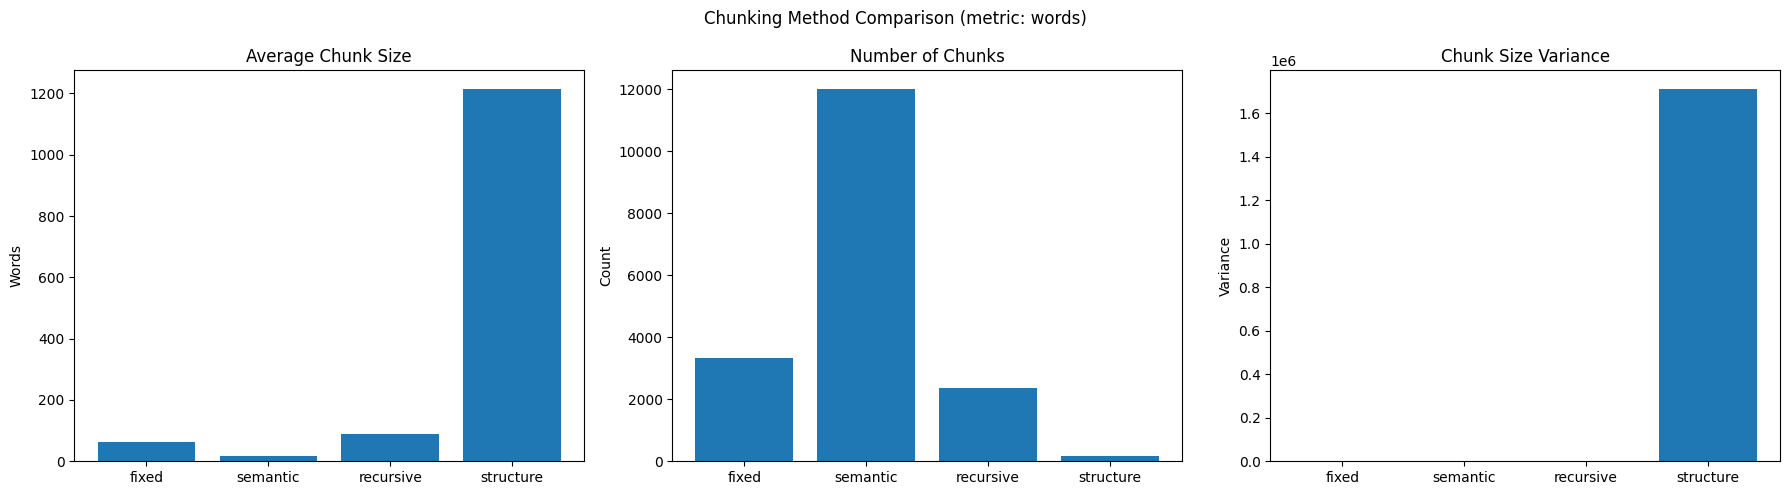

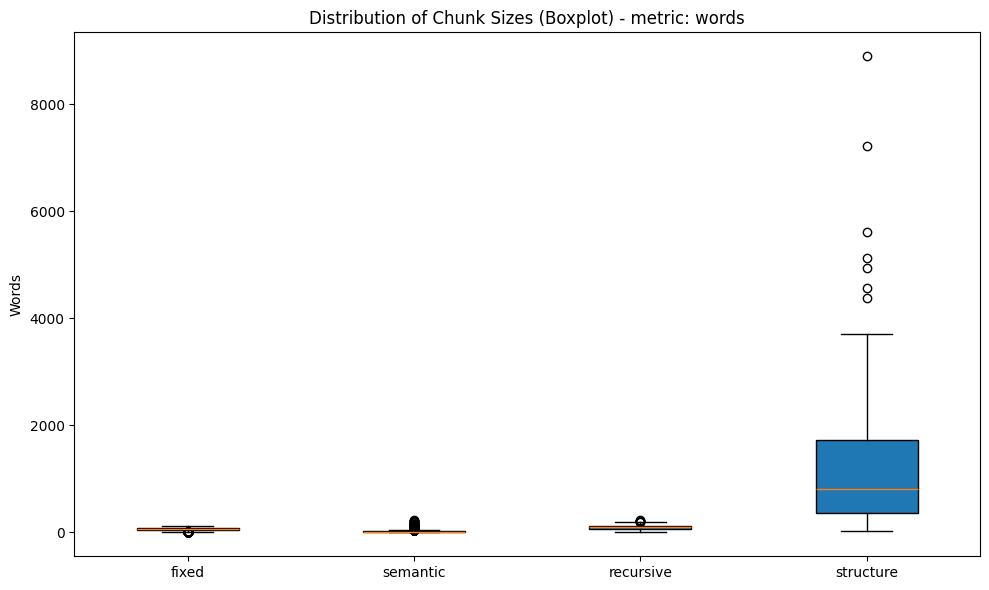

In [24]:
# ---------------------------------------
# Bar Plots (using computed df)
# ---------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Average chunk size
axes[0].bar(df["Method"], df["Avg Chunk Size"])
axes[0].set_title("Average Chunk Size")
axes[0].set_ylabel({
    "chars": "Characters",
    "words": "Words",
    "tokens": "Tokens"
}[METRIC])

# Number of chunks
axes[1].bar(df["Method"], df["Num Chunks"])
axes[1].set_title("Number of Chunks")
axes[1].set_ylabel("Count")

# Variance
axes[2].bar(df["Method"], df["Size Variance"])
axes[2].set_title("Chunk Size Variance")
axes[2].set_ylabel("Variance")

plt.suptitle(f"Chunking Method Comparison (metric: {METRIC})")

plt.tight_layout()
plt.show()


# ---------------------------------------
# Boxplot from raw chunk sizes
# ---------------------------------------

def extract_sizes(chunks, metric: str):
    return [_size_val(c, metric) for c in chunks]


sizes_fixed = extract_sizes(chunked_pages, METRIC)
sizes_semantic = extract_sizes(semantic_chunked_pages, METRIC)
sizes_recursive = extract_sizes(recursive_chunked_pages, METRIC)
sizes_structure = extract_sizes(structure_chunked_pages, METRIC)
#sizes_llm = extract_sizes(llm_chunked_pages, METRIC) # Removed LLM due to previous error

plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        sizes_fixed,
        sizes_semantic,
        sizes_recursive,
        sizes_structure
        #sizes_llm # Removed LLM due to previous error
    ],
    tick_labels=["fixed", "semantic", "recursive", "structure"], # Updated parameter name
    patch_artist=True
)

plt.title(f"Distribution of Chunk Sizes (Boxplot) - metric: {METRIC}")

plt.ylabel({
    "chars": "Characters",
    "words": "Words",
    "tokens": "Tokens"
}[METRIC])

plt.tight_layout()
plt.show()


Structure-based chunking Produced the largest chunks, fewer in number, but with very high variance.

Best for capturing entire sections/chapters, less balanced for downstream models.

Semantic chunking → Produced very small chunks and the highest number of chunks. Preserves fine-grained context, but risks over-fragmentation.

Fixed-size chunking Produced consistent, moderate chunks with low variance. Predictable sizing, but ignores semantic boundaries.

Recursive chunking→ A balanced approach, moderate variance, and reasonable number of chunks. Good compromise between coherence and consistency.

LLM chunking Produced moderate number of chunks with moderate variance, but required highest computational time. **bold text**

In [25]:
from spacy.lang.en import English
from tqdm.auto import tqdm
import random

# -----------------------------
# Create NLP pipeline
# -----------------------------
nlp = English()

# Add sentencizer component
nlp.add_pipe("sentencizer")

# Example test
doc = nlp("This is a sentence. This is another sentence.")
assert len(list(doc.sents)) == 2


# -----------------------------
# Define sentence chunk size
# -----------------------------
num_sentence_chunk_size = 10


# -----------------------------
# Function to split list into chunks
# -----------------------------
def split_list(input_list: list, slice_size: int) -> list[list]:
    """
    Splits input_list into sublists of size slice_size.
    Example:
        17 sentences -> [[10], [7]]
    """
    return [
        input_list[i:i + slice_size]
        for i in range(0, len(input_list), slice_size)
    ]


# -----------------------------
# Process pages_and_texts
# -----------------------------
for item in tqdm(pages_and_texts, desc="Sentence chunking"):

    # Convert text to sentences
    doc = nlp(item["text"])
    sentences = [sent.text.strip() for sent in doc.sents]

    # Store sentences
    item["sentences"] = sentences

    # Split into sentence chunks
    item["sentence_chunks"] = split_list(
        input_list=sentences,
        slice_size=num_sentence_chunk_size
    )

    # Count number of chunks
    item["num_chunks"] = len(item["sentence_chunks"])


# -----------------------------
# Sample example
# -----------------------------
print(random.sample(pages_and_texts, k=1))

Sentence chunking:   0%|          | 0/1208 [00:00<?, ?it/s]

[{'page_number': 442, 'page_char_count': 1668, 'page_word_count': 224, 'page_sentence_count_raw': 39, 'page_token_count_estimate': 417.0, 'text': 'how proteins, specifically those in red and processed meats, causes  colon cancer is not known and requires further study.  Some scientists hypothesize that high-protein diets may  accelerate bone-tissue loss because under some conditions the  acids in protein block absorption of calcium in the gut, and, once  in the blood, amino acids promote calcium loss from bone; however  even these effects have not been consistently observed in scientific  studies. Results from the Nurses’ Health Study suggest that women  who eat more than 95 grams of protein each day have a 20 percent  higher risk for wrist fracture.23  Other studies have not produced consistent results. The scientific  data on high protein diets and increased risk for osteoporosis  remains highly controversial and more research is needed to come  to any conclusions about the associati

In [26]:
# Create DataFrame
df = pd.DataFrame(pages_and_texts)

# Show descriptive statistics
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count_estimate,num_chunks
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,603.50,1148.00,171.97,14.18,287.00,1.53
std,348.86,560.38,86.49,9.54,140.10,0.64
min,0.00,0.00,0.00,1.00,0.00,0.00
25%,301.75,762.00,109.00,8.00,190.50,1.00
50%,603.50,1231.50,183.00,13.00,307.88,1.00
75%,905.25,1603.50,239.00,19.00,400.88,2.00
max,1207.00,2308.00,393.00,82.00,577.00,3.00


**Splitting each chunk into its own item**

We'd like to embed each chunk of sentences into its own numerical representation.

So to keep things clean, let's create a new list of dictionaries each containing a single chunk of sentences with relative information such as page number as well statistics about each chunk.

In [27]:
import re
from tqdm.auto import tqdm

# ----------------------------------------
# Split each sentence chunk into its own item
# ----------------------------------------

pages_and_chunks = []

for item in tqdm(pages_and_texts, desc="Building chunk list"):

    for sentence_chunk in item["sentence_chunks"]:

        chunk_dict = {}

        # Page reference
        chunk_dict["page_number"] = item["page_number"]

        # Join sentences into single string
        joined_sentence_chunk = " ".join(sentence_chunk).strip()

        # Fix missing space after period (".A" -> ". A")
        joined_sentence_chunk = re.sub(
            r'\.([A-Z])',
            r'. \1',
            joined_sentence_chunk
        )

        chunk_dict["sentence_chunk"] = joined_sentence_chunk

        # -------------------------
        # Stats
        # -------------------------
        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)

        chunk_dict["chunk_word_count"] = len(joined_sentence_chunk.split())

        # Rough token estimate (1 token ≈ 4 chars)
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4

        pages_and_chunks.append(chunk_dict)


# ----------------------------------------
# Total chunks
# ----------------------------------------

print("Total chunks:", len(pages_and_chunks))

Building chunk list:   0%|          | 0/1208 [00:00<?, ?it/s]

Total chunks: 1843


In [28]:
random.sample(pages_and_chunks,k=1)

[{'page_number': 1077,
  'sentence_chunk': 'kept at 0°F (or −18°C). Store potatoes and onions in a cool, dark  place, but not under a sink because leakage from pipes could  contaminate them. Empty cans of perishable foods or beverages  that have been opened into containers, and promptly place them in  a refrigerator. Also, be sure to consume leftovers within three to five  days, so mold does not have a chance to grow. Preparing Food  Wash hands thoroughly with warm, soapy water for at least twenty  seconds before preparing food and every time after handling raw  foods. Washing hands is important for many reasons. One is to  prevent cross-contamination between foods. Also, some pathogens  can be passed from person to person, so hand washing can help  to prevent this. Fresh fruits and vegetables should also be rinsed  thoroughly under running water to clean off pesticide residue2. This is particularly important for produce that contains a high  level of residue, such as apples, pears, sp

In [29]:
df=pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,1843.00,1843.00,1843.00,1843.00
mean,624.38,750.05,112.88,187.51
std,347.79,455.70,71.28,113.92
min,0.00,14.00,3.00,3.50
25%,321.50,321.50,45.00,80.38
50%,627.00,760.00,115.00,190.00
75%,931.00,1137.50,173.00,284.38
max,1207.00,1871.00,298.00,467.75


In [30]:
# Show random chunks with under 30 tokens in length

min_token_length = 30

for _, row in df[df["chunk_token_count"] <= min_token_length].sample(5).iterrows():
    print(f'Chunk token count: {row["chunk_token_count"]} | Text: {row["sentence_chunk"]}')

Chunk token count: 3.75 | Text: 814  |  Infancy
Chunk token count: 21.75 | Text: Centers for Disease Control  and Prevention. http://www.cdc.gov/nutrition/ Iron  |  661
Chunk token count: 14.25 | Text: PART IX  CHAPTER 9. VITAMINS  Chapter 9. Vitamins  |  513
Chunk token count: 18.0 | Text: PART XI  CHAPTER 11. TRACE  MINERALS  Chapter 11. Trace Minerals  |  649
Chunk token count: 18.0 | Text: The Obesity Myth. Gotham Books. Calories In Versus Calories Out  |  1069


To only include chunks with over 30 tokens in length

In [31]:
min_token_length = 30
pages_and_chunks_over_min_token_len = df[
    df["chunk_token_count"] > min_token_length
].to_dict(orient="records")

pages_and_chunks_over_min_token_len[:2]

[{'page_number': 2,
  'sentence_chunk': 'Human Nutrition: 2020  Edition  UNIVERSITY OF HAWAI‘I AT MĀNOA  FOOD SCIENCE AND HUMAN  NUTRITION PROGRAM  ALAN TITCHENAL, SKYLAR HARA,  NOEMI ARCEO CAACBAY, WILLIAM  MEINKE-LAU, YA-YUN YANG, MARIE  KAINOA FIALKOWSKI REVILLA,  JENNIFER DRAPER, GEMADY  LANGFELDER, CHERYL GIBBY, CHYNA  NICOLE CHUN, AND ALLISON  CALABRESE',
  'chunk_char_count': 320,
  'chunk_word_count': 42,
  'chunk_token_count': 80.0},
 {'page_number': 3,
  'sentence_chunk': 'Human Nutrition: 2020 Edition by University of Hawai‘i at Mānoa Food Science and  Human Nutrition Program is licensed under a Creative Commons Attribution 4.0  International License, except where otherwise noted.',
  'chunk_char_count': 212,
  'chunk_word_count': 30,
  'chunk_token_count': 53.0}]

# **Embedding our text chunks**




While humans understand text, machines understand numbers best.

An embedding is a broad concept.

But one of my favourite and simple definitions is "a useful numerical representation".

The most powerful thing about modern embeddings is that they are learned representations.

Meaning rather than directly mapping words/tokens/characters to numbers directly (e.g. {"a": 0, "b": 1, "c": 3...}), the numerical representation of tokens is learned by going through large corpuses of text and figuring out how different tokens relate to ea other.

Ideally, embeddings of text will mean that similar meaning texts have similar numerical representation.

*Note:* Most modern NLP models deal with "tokens" which can be considered as multiple different sizes and combinations of words and characters rather than always whole words or single characters. For example, the string "hello world!" gets mapped to the token values (15339: b'hello', 1917: b' world', 0: b'!'} using Byte pair encoding (or BPE via OpenAl's tiktoken library). Google has a tokenization library called SentencePiece.

Our goal is to turn each of our chunks into a numerical representation (an embedding vector, where a vector is a sequence of numbers arranged in order).

Once our text samples are in embedding vectors, us humans will no longer be able to understand them.

However, we don't need to.

The embedding vectors are for our computers to understand.

We'll use our computers to find patterns in the embeddings and then we can use their text mappings to further our understanding.

Enough talking, how about we import a text embedding model and see what an embedding looks like.

# To do so, we'll use the sentence-transformers library which contains many pre-trained embedding models.

# Specifically, we'll get the all-mpnet-base-v2 model (you can see the model's intended use on the Hugging Face model card).

In [32]:
from sentence_transformers import SentenceTransformer

# Load embedding model
embedding_model = SentenceTransformer(
    model_name_or_path="all-mpnet-base-v2",
    device="cpu"  # use "cuda" if you have a GPU
)

# Create a list of sentences
sentences = [
    "The Sentence Transformers library provides an easy and open-source way to create embeddings.",
    "Sentences can be embedded one by one or as a list of strings.",
    "Embeddings are one of the most powerful concepts in machine learning!",
    "Learn to use embeddings well and you'll be well on your way to being an AI engineer."
]

# Encode sentences into embeddings
embeddings = embedding_model.encode(sentences)

# Map sentences to embeddings
embeddings_dict = dict(zip(sentences, embeddings))

# Print embeddings
for sentence, embedding in embeddings_dict.items():
    print("Sentence:", sentence)
    print("Embedding:", embedding)
    print()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence: The Sentence Transformers library provides an easy and open-source way to create embeddings.
Embedding: [-1.99157391e-02  4.11678702e-02 -1.88775118e-02  6.57408386e-02
 -2.30734479e-02 -1.51006570e-02 -4.05880623e-03 -5.91936409e-02
  1.37240058e-02 -2.86808591e-02  3.22586820e-02  4.60162275e-02
 -5.52314855e-02  2.82665212e-02  3.58073153e-02 -4.94717211e-02
  4.60460633e-02 -1.21009175e-03 -1.34466710e-02  1.09683545e-02
  5.23573942e-02  4.38404046e-02  1.95453353e-02  5.30938134e-02
 -2.13442780e-02 -3.15952823e-02  4.08161618e-03 -2.61570886e-02
  4.53445725e-02  4.33318433e-04 -1.21952686e-02 -4.62408131e-03
  4.08580117e-02  1.90961193e-02  8.43359942e-07 -3.83119960e-03
 -2.27001924e-02  1.94589398e-03  8.51299148e-03  3.13566718e-03
  5.54311313e-02 -5.54998554e-02  1.08442148e-02  4.87203114e-02
 -3.79324183e-02 -9.71970498e-04  4.15215120e-02  2.44229473e-02
  9.37566459e-02  5.95447980e-02 -1.81962401e-02 -3.27963717e-02
  7.00938795e-03 -7.03645777e-03 -3.45217

Let's Start by trying to create embeddings on the CPU , we will time it by %%time and see how much time it takes

In [ ]:
%%time

from tqdm import tqdm

# Make sure the model is on CPU
embedding_model.to("cpu")

# Embed each chunk one by one
for item in tqdm(pages_and_chunks_over_min_token_len):
    item["embedding"] = embedding_model.encode(item["sentence_chunk"])

 76%|███████▋  | 1286/1684 [14:49<04:02,  1.64it/s]

GPU Embedding

In [ ]:
%%time

from tqdm import tqdm

# Send the model to GPU
embedding_model.to("cuda")  # Requires a CUDA-compatible GPU

# Create embeddings one by one on the GPU
for item in tqdm(pages_and_chunks_over_min_token_len):
    item["embedding"] = embedding_model.encode(item["sentence_chunk"])

Batched GPU Embedding

In [ ]:
%%time

# Turn text chunks into a single list
text_chunks = [item["sentence_chunk"] for item in pages_and_chunks_over_min_token_len]

# Embed all texts in batches
text_chunk_embeddings = embedding_model.encode(
    text_chunks,
    batch_size=32,          # you can increase this depending on GPU memory
    convert_to_tensor=True  # return embeddings as PyTorch tensors
)

text_chunk_embeddings

**Saving the Embeddings to a file**

In [ ]:
import pandas as pd

# Save embeddings to file
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)

embeddings_df_save_path = "text_chunks_and_embeddings_df.csv"

text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

In [ ]:
# Import saved file
text_chunks_and_embedding_df_load = pd.read_csv(embeddings_df_save_path)

# View first 5 rows
text_chunks_and_embedding_df_load.head()

In [ ]:
import random
import torch
import numpy as np
import pandas as pd

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load CSV
text_chunks_and_embedding_df = pd.read_csv("text_chunks_and_embeddings_df.csv")

# Convert embedding column (string → numpy array)
# Fixed: Use a more robust parsing method for space-separated numbers
text_chunks_and_embedding_df["embedding"] = text_chunks_and_embedding_df["embedding"].apply(
    lambda x: np.array([float(num) for num in x.strip("[]").split(' ') if num])
)

# Convert DataFrame → list of dicts
pages_and_chunks = text_chunks_and_embedding_df.to_dict(orient="records")

# Convert embeddings → torch tensor
embeddings = torch.tensor(
    np.array(text_chunks_and_embedding_df["embedding"].tolist()),
    dtype=torch.float32
).to(device)

# Check shape
print("Embeddings shape:", embeddings.shape)
print("Device:", embeddings.device)

In [ ]:
from sentence_transformers import util
from time import perf_counter as timer
import torch

# 1. Define the query
query = "macronutrients functions"
print(f"Query: {query}")

# 2. Embed the query (same model as chunks!)
query_embedding = embedding_model.encode(query, convert_to_tensor=True).to(device)

# 3. Compute similarity scores
start_time = timer()

dot_scores = util.dot_score(query_embedding, embeddings)[0]

end_time = timer()

print(f"Time taken to get scores on {len(embeddings)} embeddings: {end_time - start_time:.5f} seconds")

# 4. Get top-k results
top_results_dot_product = torch.topk(dot_scores, k=5)

top_results_dot_product

In [ ]:
from sentence_transformers import util
from time import perf_counter as timer
import torch

# Create larger embeddings (simulate scale)
larger_embeddings = torch.randn(
    100 * embeddings.shape[0], 768
).to(device)

print(f"Embeddings shape: {larger_embeddings.shape}")

# Perform dot product across large embeddings
start_time = timer()

dot_scores = util.dot_score(query_embedding, larger_embeddings)[0]

end_time = timer()

print(f"Time taken to get scores on {len(larger_embeddings)} embeddings: {end_time - start_time:.5f} seconds")

In [ ]:
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, width=wrap_length)
    print(wrapped_text)

In [ ]:
print(f"Query: {query}\n")

print("Results:\n")

# Loop through scores and indices from torch.topk
for score, idx in zip(top_results_dot_product.values, top_results_dot_product.indices):

    print(f"Score: {score:.4f}")

    print("Text:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])

    # Print page number for reference
    print(f"Page number: {pages_and_chunks[idx]['page_number']}")

    print("\n")

**core retrieval function of our RAG pipeline**

In [ ]:
from sentence_transformers import util
from time import perf_counter as timer
import torch


def retrieve_relevant_resources(
    query: str,
    embeddings: torch.Tensor,
    model,
    n_resources_to_return: int = 5,
    print_time: bool = True
):
    """
    Embeds a query and returns top-k scores and indices from embeddings.
    """

    # 1. Embed the query
    query_embedding = model.encode(query, convert_to_tensor=True).to(embeddings.device)

    # 2. Compute similarity scores
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time - start_time:.5f} seconds")

    # 3. Get top-k results
    scores, indices = torch.topk(dot_scores, k=n_resources_to_return)

    return scores, indices


def print_top_results_and_scores(
    query: str,
    embeddings: torch.Tensor,
    pages_and_chunks: list[dict],
    model,
    n_resources_to_return: int = 5
):
    """
    Takes a query, retrieves most relevant resources, and prints them.
    """

    scores, indices = retrieve_relevant_resources(
        query=query,
        embeddings=embeddings,
        model=model,
        n_resources_to_return=n_resources_to_return
    )

    print(f"\nQuery: {query}\n")
    print("Results:\n")

    for score, index in zip(scores, indices):
        print(f"Score: {score:.4f}")
        print("Text:")
        print_wrapped(pages_and_chunks[index]["sentence_chunk"])

        print(f"Page number: {pages_and_chunks[index]['page_number']}")
        print("\n")

In [ ]:
query = "symptoms of pellagra"

# Get scores and indices
scores, indices = retrieve_relevant_resources(
    query=query,
    embeddings=embeddings,
    model=embedding_model   # ❗ REQUIRED
)

scores, indices

In [ ]:
print_top_results_and_scores(
    query=query,
    embeddings=embeddings,
    pages_and_chunks=pages_and_chunks,
    model=embedding_model
)

**Seeing the local avaiable GPU space for the correct and fit LLM Model**

In [ ]:
import torch

if torch.cuda.is_available():
    gpu_memory_bytes = torch.cuda.get_device_properties(0).total_memory
    gpu_memory_gb = round(gpu_memory_bytes / (2**30), 2)

    print(f"Available GPU memory: {gpu_memory_gb} GB")
else:
    print("No GPU available.")

In [ ]:
# Decide model based on available GPU memory

if gpu_memory_gb < 5.1:
    print(f"Your available GPU memory is {gpu_memory_gb} GB, you may not have enough memory to run a Gemma LLM locally without quantization.")

    use_quantization_config = True
    model_id = "google/gemma-2b-it"

elif gpu_memory_gb < 8.1:
    print(f"GPU memory: {gpu_memory_gb} GB | Recommended model: Gemma 2B in 4-bit precision.")

    use_quantization_config = True
    model_id = "google/gemma-2b-it"

elif gpu_memory_gb < 19.0:
    print(f"GPU memory: {gpu_memory_gb} GB | Recommended model: Gemma 2B in float16 or Gemma 7B in 4-bit precision.")

    use_quantization_config = False
    model_id = "google/gemma-2b-it"

else:
    print(f"GPU memory: {gpu_memory_gb} GB | Recommended model: Gemma 7B in float16 or 4-bit precision.")

    use_quantization_config = False
    model_id = "google/gemma-7b-it"

print(f"use_quantization_config set to: {use_quantization_config}")
print(f"model_id set to: {model_id}")

In [ ]:
from huggingface_hub import login

# Paste your Hugging Face token here
login(token="YOUR_HF_TOKEN")


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from transformers.utils import is_flash_attn_2_available

# 1. Quantization config (optional)
use_quantization_config = True  # set this based on your GPU memory

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

# 2. Attention implementation
if is_flash_attn_2_available() and torch.cuda.get_device_capability(0)[0] >= 8:
    attn_implementation = "flash_attention_2"
else:
    attn_implementation = "sdpa"

print(f"[INFO] Using attention implementation: {attn_implementation}")

# 3. Model selection (already set earlier)
# example fallback:
# model_id = "google/gemma-2b-it"

print(f"[INFO] Using model_id: {model_id}")

# 4. Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

# 5. Load model
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    quantization_config=quantization_config if use_quantization_config else None,
    low_cpu_mem_usage=True,
    attn_implementation=attn_implementation
)

# 6. Move to GPU (only if NOT using quantization)
if not use_quantization_config:
    model.to("cuda")

print("[INFO] Model loaded successfully")

In [ ]:
model

In [ ]:
def get_model_num_params(model: torch.nn.Module):
    return sum(param.numel() for param in model.parameters())

# Call it
get_model_num_params(model)

In [ ]:
def get_model_mem_size(model: torch.nn.Module):
    """
    Get how much memory a PyTorch model takes up.
    """

    # Parameters memory
    mem_params = sum(param.nelement() * param.element_size() for param in model.parameters())

    # Buffers memory
    mem_buffers = sum(buf.nelement() * buf.element_size() for buf in model.buffers())

    # Total memory
    model_mem_bytes = mem_params + mem_buffers
    model_mem_mb = model_mem_bytes / (1024 ** 2)
    model_mem_gb = model_mem_bytes / (1024 ** 3)

    return {
        "model_mem_bytes": model_mem_bytes,
        "model_mem_mb": round(model_mem_mb, 2),
        "model_mem_gb": round(model_mem_gb, 2)
    }


# Call it
get_model_mem_size(model)

In [ ]:
input_text = "What are the macronutrients, and what roles do they play in the human body?"

print(f"Input text:\n{input_text}")

# Create prompt template for instruction-tuned model
dialogue_template = [
    {
        "role": "user",
        "content": input_text
    }
]

# Apply the chat template
prompt = tokenizer.apply_chat_template(
    conversation=dialogue_template,
    tokenize=False,                # keep as raw text
    add_generation_prompt=True     # add assistant prefix
)

print(f"\nPrompt (formatted):\n{prompt}")

In [ ]:
%%time

# Tokenize the prompt and send to GPU
input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

print(f"Model input (tokenized):\n{input_ids}\n")

# Generate output
outputs = model.generate(
    **input_ids,
    max_new_tokens=256
)

print(f"Model output (tokens):\n{outputs[0]}\n")

In [ ]:
# Decode the output tokens to text
outputs_decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(f"Model output (decoded):\n{outputs_decoded}\n")

In [ ]:
print(f"Input text: {input_text}\n")

clean_output = outputs_decoded.replace(prompt, "").replace("<bos>", "").replace("<eos>", "").strip()

print(f"Output text:\n{clean_output}")

In [ ]:
def prompt_formatter(query: str, context_items: list[dict]) -> str:
    """
    Augments query with text-based context from retrieved chunks.
    """

    # 1. Join context items into a bullet-style paragraph
    context = "- " + "\n- ".join([item["sentence_chunk"] for item in context_items])

    # 2. Base prompt with examples
    base_prompt = """Based on the following context items, please answer the query.

Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.

Use the following examples as reference for the ideal answer style:

Example 1:
Query: What are the fat-soluble vitamins?
Answer: The fat-soluble vitamins include Vitamin A, Vitamin D, Vitamin E, and Vitamin K. These vitamins are absorbed along with fat.

Example 2:
Query: What are the causes of type 2 diabetes?
Answer: Type 2 diabetes is often associated with overnutrition, particularly excess calorie intake leading to obesity.

Example 3:
Query: What is the importance of hydration for physical performance?
Answer: Hydration is crucial for physical performance because water helps maintain blood volume, regulate body temperature, and support muscle function.

Now use the following context items to answer the user query:

{context}

The context contains the answer. Extract relevant information carefully.

User query: {query}

Answer:
"""

    # 3. Inject context + query
    base_prompt = base_prompt.format(context=context, query=query)

    # 4. Convert into chat format
    dialogue_template = [
        {"role": "user", "content": base_prompt}
    ]

    # 5. Apply tokenizer chat template
    prompt = tokenizer.apply_chat_template(
        conversation=dialogue_template,
        tokenize=False,
        add_generation_prompt=True
    )

    return prompt

In [ ]:
import random

# Pick a random query
query = random.choice(query_list)

print(f"Query: {query}")

# Get relevant resources
scores, indices = retrieve_relevant_resources(
    query=query,
    embeddings=embeddings,
    model=embedding_model
)

# Create a list of context items
context_items = [pages_and_chunks[i] for i in indices]

# Format prompt with context
prompt = prompt_formatter(
    query=query,
    context_items=context_items
)

print(prompt)

In [ ]:
import random

# Define a list of example queries
query_list = [
    "What are the macronutrients, and what roles do they play in the human body?",
    "symptoms of pellagra",
    "What is the importance of hydration for physical performance?",
    "What are the fat-soluble vitamins?",
    "What are the causes of type 2 diabetes?"
]

# Pick a random query
query = random.choice(query_list)

print(f"Query: {query}")

# Get relevant resources
scores, indices = retrieve_relevant_resources(
    query=query,
    embeddings=embeddings,
    model=embedding_model
)

# Create a list of context items
context_items = [pages_and_chunks[i] for i in indices]

# Format prompt with context
prompt = prompt_formatter(
    query=query,
    context_items=context_items
)

print(prompt)

In [ ]:
%%time

# Tokenize prompt and move to GPU
input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

# Generate output tokens
outputs = model.generate(
    **input_ids,
    temperature=0.7,        # controls randomness
    do_sample=True,         # enables sampling
    max_new_tokens=256      # max tokens to generate
)

# Decode tokens to text
output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

# Clean output (remove prompt if repeated)
clean_output = output_text.replace(prompt, "").strip()

print(f"Query: {query}\n")
print(f"RAG answer:\n{clean_output}")

In [ ]:
def ask(
    query: str,
    temperature: float = 0.7,
    max_new_tokens: int = 512,
    format_answer_text: bool = True,
    return_answer_only: bool = True
):
    """
    Takes a query, retrieves relevant context, and generates an answer.
    """

    # 1. Retrieve relevant resources
    scores, indices = retrieve_relevant_resources(
        query=query,
        embeddings=embeddings,
        model=embedding_model
    )

    # 2. Build context items
    context_items = [pages_and_chunks[i] for i in indices]

    # 3. Attach scores to context
    for i, item in enumerate(context_items):
        item["score"] = scores[i].item()

    # 4. Format prompt
    prompt = prompt_formatter(
        query=query,
        context_items=context_items
    )

    # 5. Tokenize + move to GPU
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    # 6. Generate response
    outputs = model.generate(
        **inputs,
        temperature=temperature,
        do_sample=True,
        max_new_tokens=max_new_tokens
    )

    # 7. Decode output
    output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # 8. Clean output
    if format_answer_text:
        output_text = (
            output_text
            .replace(prompt, "")
            .replace("<bos>", "")
            .replace("<eos>", "")
            .replace("Sure, here is the answer to the user query:\n\n", "")
            .strip()
        )

    # 9. Return result
    if return_answer_only:
        return output_text

    return output_text, context_items

In [ ]:
import random

# Pick a random query
query = random.choice(query_list)

print(f"Query: {query}")

# Answer query and return context
answer, context_items = ask(
    query=query,
    temperature=0.7,
    max_new_tokens=512,
    return_answer_only=False
)

print("\nAnswer:\n")
print_wrapped(answer)

print("\nContext items:")
print(context_items)